# Assignment 4 (new data) — 1. BRFSS diabetes (tabular)

**One learning problem, three implementations: NumPy from scratch, TensorFlow/Keras, and PyTorch.**

This is the tabular dataset of the new collection, and it plays the same role the Diabetes 130-US hospitals
data played in `01_diabetes130.ipynb`: the **control case** that shows a CNN is a choice justified by the
data, not a default.

| # | Dataset | Structure | Model family |
|---|---------|-----------|--------------|
| **A** | **BRFSS diabetes 2015+2023** | tabular, 19 features | **MLP** |
| B | Rice images | image, 3×32×32 | CNN |
| C | Intel scenes | image, 3×64×64 | CNN |

### Why an MLP and not a CNN

Lecture 04, slide 4. A tabular row

$$x = [x_1, x_2, \dots, x_d]$$

has no two-dimensional neighbourhood: `BMI` is not spatially adjacent to `Smoker` the way two pixels are.
Convolution exists to exploit local spatial structure, so where there is none its two defining ideas —
local connectivity and weight sharing — buy nothing.

$$\textbf{BRFSS} \rightarrow \text{MLP} \qquad\qquad \textbf{Rice / Intel} \rightarrow \text{CNN}$$

### What is different from the old diabetes notebook

The previous tabular dataset was 101,766 hospital encounters expanded to 179 one-hot features. This one is
**546,166 survey responses across 19 already-numeric features** — five times the rows, a tenth of the
width. That changes the story in two useful ways:

1. Every leg trains on the **full dataset**, including the from-scratch one. In the old notebooks the NumPy
   leg had to fall back to subsets on the image data; here all three see the same 436,933 training rows,
   so the comparison is as clean as the fairness rule can make it.
2. The class imbalance is **far more severe** — 84 / 2 / 14 rather than 59 / 32 / 9 — which makes §4.2 of
   `theory_notes.md` the centre of this notebook rather than a footnote.

### The fairness rule

Slide 29:

> Same Dataset **+** Same Split **+** Same Architecture **+** Comparable Hyperparameters

All three legs below pull their arrays from one `ass4_newdata` call with one seed, so they see
byte-identical training and test sets. Only the *level of abstraction* changes.

In [1]:
import os, sys, json, time, platform

# TensorFlow is CPU-only on Windows (no GPU support since 2.10); silence its startup chatter.
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))        # notebook/  -> ass4_newdata
sys.path.insert(0, os.path.abspath(".."))       # repo root  -> ass4_utils, scratch_nn

import ass4_newdata as D
import ass4_utils as U
import scratch_nn as S

U.set_seed(U.SEED)

import torch
import tensorflow as tf
import keras

print("python     ", platform.python_version())
print("numpy      ", np.__version__)
print("torch      ", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("tensorflow ", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")
print("keras      ", keras.__version__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Outputs stay inside notebook/: weights in notebook/models/, metrics in
# notebook/results/. The six original notebooks keep theirs under the repo-root
# results/, so nothing here can overwrite them.
RESULTS = D.notebook_results_dir()
MODELS = D.use_notebook_model_dir()
print("weights ->", os.path.relpath(MODELS, D.ROOT))
print("metrics ->", os.path.relpath(RESULTS, D.ROOT))
plt.rcParams["figure.dpi"] = 110

python      3.11.8
numpy       2.2.6
torch       2.10.0+cu130 | CUDA: True | NVIDIA GeForce RTX 3060 Laptop GPU


tensorflow  2.21.0 | GPUs: none (CPU)
keras       3.15.1
weights -> notebook\models
metrics -> notebook\results


---
## 1. The data

`data/diabetes_brfss_2015_2023.csv` merges two CDC **BRFSS** survey cycles — the 2015 and 2023 Behavioral
Risk Factor Surveillance System — into 546,166 rows × 20 columns with no missing values. The merge itself
is documented in `data/diabetes_info.md`; notebook `00_inventory.ipynb` verifies its claims against the
file on disk.

The loader in `ass4_newdata.py` does only what is left:

1. **Split off the target** `Diabetes_012` — 0 = none, 1 = prediabetes, 2 = diabetes.
2. **Keep every row.** The file contains 67,731 exact duplicates. They are *not* dropped: with only 19
   coarse discrete answers describing 546k people, distinct respondents collide by chance. The info file
   is explicit that they are genuine, and that all of them fall *within* a single survey year rather than
   across the merge boundary.
3. **Shuffle and split 80/20** with seed 42.
4. **Standardise** every column using *training* statistics only.

No one-hot encoding is needed — unlike the hospital dataset, every column already arrives as a number.

In [2]:
X_train, y_train, X_test, y_test, meta = D.load_diabetes_brfss()

N_FEATURES = X_train.shape[1]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

print(f"\ntrain {X_train.shape}   test {X_test.shape}   dtype {X_train.dtype}")
print(f"features: {N_FEATURES}   classes: {CLASSES}")
print(f"split   : {meta['split']}")
print(f"\nfeature names: {meta['feature_names']}")

BRFSS diabetes 2015+2023: raw (546166, 20) -> train (436933, 19) / test (109233, 19), 19 features, 3 classes (random 80%/20%, seed 42)

train (436933, 19)   test (109233, 19)   dtype float32
features: 19   classes: ['no diabetes', 'prediabetes', 'diabetes']
split   : random 80%/20%, seed 42

feature names: ['year', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [3]:
# Standardisation is worth checking rather than trusting: `year` holds values
# around 2019, and a float32 column sum over 437k rows is large enough to lose
# precision. ass4_newdata accumulates in float64 for exactly this reason.
col_mean = X_train.mean(axis=0)
col_std = X_train.std(axis=0)
print(f"worst |column mean| on train: {np.abs(col_mean).max():.2e}   (should be ~0)")
print(f"column std range on train   : {col_std.min():.4f} .. {col_std.max():.4f}   (should be ~1)")
print(f"test set mean (uses TRAIN statistics, so not forced to 0): {X_test.mean():+.4f}")

worst |column mean| on train: 6.65e-06   (should be ~0)
column std range on train   : 0.9977 .. 1.0021   (should be ~1)
test set mean (uses TRAIN statistics, so not forced to 0): -0.0006


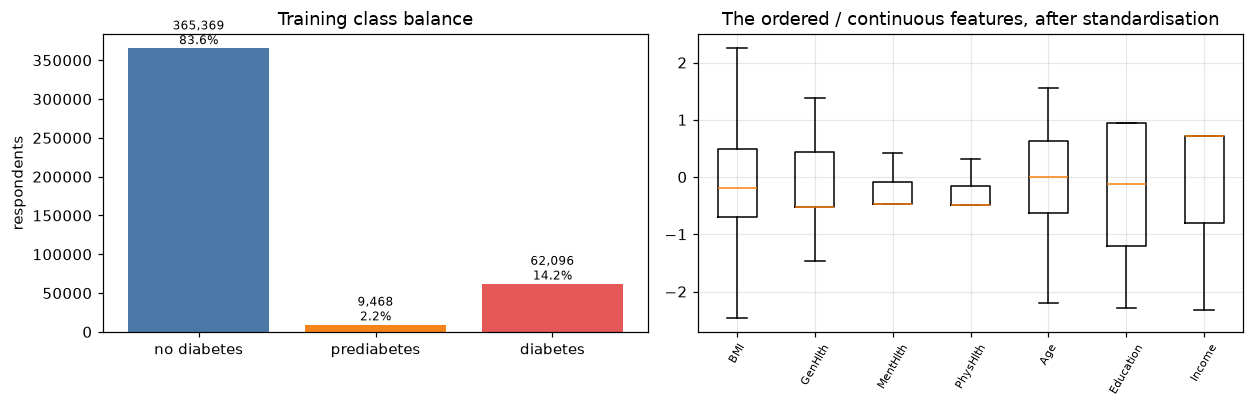

class                        train    share
no diabetes                365,369   83.62%
prediabetes                  9,468    2.17%
diabetes                    62,096   14.21%


In [4]:
# Class balance and the shape of the standardised features.
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))

counts = np.bincount(y_train, minlength=N_CLASSES)
bars = ax[0].bar(CLASSES, counts, color=["#4C78A8", "#F58518", "#E45756"])
ax[0].set_title("Training class balance")
ax[0].set_ylabel("respondents")
for b, c in zip(bars, counts):
    ax[0].text(b.get_x() + b.get_width() / 2, c, f"{c:,}\n{c/counts.sum():.1%}",
               ha="center", va="bottom", fontsize=8)

numeric = meta["numeric_features"]
idx = [meta["feature_names"].index(n) for n in numeric]
ax[1].boxplot([X_train[:, i] for i in idx], tick_labels=numeric, showfliers=False)
ax[1].set_title("The ordered / continuous features, after standardisation")
ax[1].tick_params(axis="x", rotation=60, labelsize=7)
ax[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

print(f"{'class':<24}{'train':>10}{'share':>9}")
for i, c in enumerate(CLASSES):
    print(f"{c:<24}{counts[i]:>10,}{counts[i]/counts.sum():>9.2%}")

> **The imbalance is the headline risk on this dataset.** Answering `no diabetes` for all 109,233 test
> respondents already scores **~84 % accuracy** while being clinically worthless — it never once identifies
> a diabetic. `theory_notes.md` §4.2 shows this exact trap on the previous diabetes data, where ~61 %
> accuracy hid a macro-F1 of ~0.35. Here the gap will be wider still, because `prediabetes` is only 2.2 %
> of the data.
>
> Every table below therefore reports **macro F1** beside accuracy. Macro F1 averages the three classes
> equally, so a model that ignores the rare classes cannot hide behind the majority one. Section 7 then
> applies the fix `theory_notes.md` recommends — class weighting — and measures what it costs and buys.

---
## 2. The shared architecture

Every implementation below builds *this* function, and nothing else:

$$X \;\rightarrow\; \text{Linear}_{19\rightarrow128} \;\rightarrow\; \text{ReLU} \;\rightarrow\; \text{Dropout}_{0.3}
\;\rightarrow\; \text{Linear}_{128\rightarrow64} \;\rightarrow\; \text{ReLU} \;\rightarrow\; \text{Linear}_{64\rightarrow3} \;\rightarrow\; \hat{y}$$

which is the tutorial's central claim made concrete — a network *is* a composition of functions:

$$F = f_5 \circ f_4 \circ f_3 \circ f_2 \circ f_1$$

### Counting the parameters by hand first

Tutorial §43 gives the rule for a linear layer:

$$N_{\text{params}} = N_{\text{in}} N_{\text{out}} + N_{\text{out}}$$

Doing the arithmetic *before* asking any framework is the point of the exercise — each implementation is
then checked against this number, and all three must agree.

In [5]:
HIDDEN1, HIDDEN2, DROPOUT = 128, 64, 0.3
EPOCHS, BATCH_SIZE, LR = 15, 256, 1e-3

# Hand-computed, per tutorial section 43: N_in * N_out + N_out
manual = [
    (f"Linear {N_FEATURES}->128", N_FEATURES * HIDDEN1 + HIDDEN1),
    ("ReLU",                      0),
    ("Dropout 0.3",               0),
    ("Linear 128->64",            HIDDEN1 * HIDDEN2 + HIDDEN2),
    ("ReLU",                      0),
    (f"Linear 64->{N_CLASSES}",   HIDDEN2 * N_CLASSES + N_CLASSES),
]
EXPECTED_PARAMS = sum(p for _, p in manual)
ARCH = f"MLP {N_FEATURES}-{HIDDEN1}-{HIDDEN2}-{N_CLASSES}"

print(f"{'layer':<20}{'params':>10}")
print("-" * 30)
for name, p in manual:
    print(f"{name:<20}{p:>10,}")
print("-" * 30)
print(f"{'TOTAL (by hand)':<20}{EXPECTED_PARAMS:>10,}")
print(f"\narchitecture: {ARCH}")
print(f"shared hyperparameters: epochs={EPOCHS}, batch_size={BATCH_SIZE}, optimizer=Adam(lr={LR})")

results = []   # collects one U.RunResult per implementation

layer                   params
------------------------------
Linear 19->128           2,560
ReLU                         0
Dropout 0.3                  0
Linear 128->64           8,256
ReLU                         0
Linear 64->3               195
------------------------------
TOTAL (by hand)         11,011

architecture: MLP 19-128-64-3
shared hyperparameters: epochs=15, batch_size=256, optimizer=Adam(lr=0.001)


---
## 3. Implementation A — from scratch (NumPy)

No framework. `scratch_nn.py` defines each layer as an explicit function with a hand-derived gradient, and
the training loop spells out all four steps of the cycle:

$$\text{Forward} \;\rightarrow\; \text{Loss} \;\rightarrow\; \text{Gradient} \;\rightarrow\; \text{Update}$$

Adam is written out as arithmetic rather than called from a library, so nothing about the update rule is
hidden. This is the leg that makes `theory_notes.md` §1.3–1.5 concrete: backpropagation *computes* the
gradient by chain rule, and the optimizer then *uses* it.

In [6]:
U.set_seed(U.SEED)

scratch_model = S.Sequential([
    S.Dense(N_FEATURES, HIDDEN1, seed=1),
    S.ReLU(),
    S.Dropout(DROPOUT, seed=11),
    S.Dense(HIDDEN1, HIDDEN2, seed=2),
    S.ReLU(),
    S.Dense(HIDDEN2, N_CLASSES, seed=3),
])

print(scratch_model.summary(input_shape=(N_FEATURES,)))
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? "
      f"{scratch_model.n_params() == EXPECTED_PARAMS}")

layer                                 output shape              params
----------------------------------------------------------------------
Dense(19 -> 128)                      (128,)                     2,560
ReLU                                  (128,)                         0
Dropout(p=0.3)                        (128,)                         0
Dense(128 -> 64)                      (64,)                      8,256
ReLU                                  (64,)                          0
Dense(64 -> 3)                        (3,)                         195
----------------------------------------------------------------------
total                                                           11,011

matches hand count 11,011? True


### Are the hand-written gradients actually right?

Before trusting anything this model reports, the analytic gradients are checked against central finite
differences,

$$\frac{\partial \mathcal{L}}{\partial \theta_i} \;\approx\; \frac{\mathcal{L}(\theta_i + \epsilon) - \mathcal{L}(\theta_i - \epsilon)}{2\epsilon}$$

on a small batch in float64. A relative error below ~1e-4 means the backward pass derived by hand agrees
with the numerical derivative — the framework legs get this correctness for free from autodiff, so the
scratch leg has to earn it.

In [7]:
U.set_seed(U.SEED)
check_model = S.Sequential([
    S.Dense(N_FEATURES, 16, seed=1),
    S.ReLU(),
    S.Dense(16, N_CLASSES, seed=3),
])
err = S.gradient_check(check_model, X_train[:8], y_train[:8], n_samples=8)
print(f"worst relative error vs finite differences: {err:.3e}")
print("PASS - hand-derived gradients agree with the numerical derivative" if err < 1e-4
      else "FAIL - backward pass disagrees with finite differences")

worst relative error vs finite differences: 2.958e-07
PASS - hand-derived gradients agree with the numerical derivative


In [8]:
U.set_seed(U.SEED)
with U.Timer() as t_scratch:
    hist_scratch = S.fit(
        scratch_model, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        optimizer=S.Adam(LR), seed=U.SEED,
    )
print(f"\ntotal training time: {t_scratch.seconds:.1f}s")

epoch 1/15  loss 0.4457  1.7s  test_acc 0.8391


epoch 2/15  loss 0.4210  1.6s  test_acc 0.8392


epoch 3/15  loss 0.4186  1.5s  test_acc 0.8399


epoch 4/15  loss 0.4173  1.7s  test_acc 0.8408


epoch 5/15  loss 0.4165  1.8s  test_acc 0.8404


...

epoch 11/15  loss 0.4143  1.6s  test_acc 0.8388


epoch 12/15  loss 0.4141  1.6s  test_acc 0.8410


epoch 13/15  loss 0.4138  2.4s  test_acc 0.8405


epoch 14/15  loss 0.4138  1.8s  test_acc 0.8407


epoch 15/15  loss 0.4134  1.7s  test_acc 0.8403

total training time: 27.5s


In [9]:
pred = scratch_model.predict_classes(X_test)
m = U.evaluate(y_test, pred, N_CLASSES)

results.append(U.RunResult(
    framework="Scratch (NumPy)", dataset=meta["name"], model=ARCH,
    n_params=scratch_model.n_params(), epochs=EPOCHS,
    train_seconds=round(t_scratch.seconds, 2),
    train_loss=round(hist_scratch["loss"][-1], 4),
    history=hist_scratch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.8403   macro-F1 0.3919


---
## 4. Implementation B — TensorFlow / Keras

The same composition, expressed as a list of reusable layers. Compare what disappeared from our code:
the explicit loop over batches, the loss computation, the gradient and the parameter update are all now
inside `fit()`.

> **Note on hardware.** Windows-native TensorFlow has shipped without GPU support since version 2.10, so
> this leg runs on CPU while the PyTorch leg below uses the GPU where one is present. Training times are
> therefore **not** directly comparable across those two rows — the parameter counts and accuracies are.

In [10]:
U.set_seed(U.SEED)

keras_model = keras.Sequential([
    keras.layers.Input(shape=(N_FEATURES,)),
    keras.layers.Dense(HIDDEN1, activation="relu"),
    keras.layers.Dropout(DROPOUT),
    keras.layers.Dense(HIDDEN2, activation="relu"),
    keras.layers.Dense(N_CLASSES),          # raw logits, like the other two legs
], name="brfss_mlp")

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
keras_model.summary()
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? "
      f"{keras_model.count_params() == EXPECTED_PARAMS}")

Model: "brfss_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,011 (43.01 KB)

 Trainable params: 11,011 (43.01 KB)

 Non-trainable params: 0 (0.00 B)


matches hand count 11,011? True


In [11]:
U.set_seed(U.SEED)
with U.Timer() as t_keras:
    hk = keras_model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2,
    )
print(f"\ntotal training time: {t_keras.seconds:.1f}s")

Epoch 1/15


1707/1707 - 3s - 2ms/step - accuracy: 0.8403 - loss: 0.4248 - val_accuracy: 0.8401 - val_loss: 0.4180


Epoch 2/15


1707/1707 - 3s - 2ms/step - accuracy: 0.8422 - loss: 0.4176 - val_accuracy: 0.8399 - val_loss: 0.4171


Epoch 3/15


...

Epoch 14/15


1707/1707 - 2s - 1ms/step - accuracy: 0.8437 - loss: 0.4133 - val_accuracy: 0.8405 - val_loss: 0.4161


Epoch 15/15


1707/1707 - 2s - 1ms/step - accuracy: 0.8434 - loss: 0.4133 - val_accuracy: 0.8402 - val_loss: 0.4163



total training time: 41.9s


In [12]:
pred = keras_model.predict(X_test, batch_size=512, verbose=0).argmax(axis=1)
m = U.evaluate(y_test, pred, N_CLASSES)

hist_keras = {"loss": [float(v) for v in hk.history["loss"]],
              "val_acc": [float(v) for v in hk.history["val_accuracy"]]}

results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset=meta["name"], model=ARCH,
    n_params=int(keras_model.count_params()), epochs=EPOCHS,
    train_seconds=round(t_keras.seconds, 2),
    train_loss=round(hist_keras["loss"][-1], 4),
    history=hist_keras, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.8402   macro-F1 0.3823


---
## 5. Implementation C — PyTorch

The same composition again, as an `nn.Module`. PyTorch sits between the other two: the *model* is as compact
as Keras, but the *training loop* is as explicit as the scratch version —

$$\text{Zero Gradient} \rightarrow \text{Forward} \rightarrow \text{Loss} \rightarrow \text{Backward} \rightarrow \text{Update}$$

is written out line by line. What PyTorch supplies that the scratch code had to derive by hand is
`loss.backward()`: autograd.

In [13]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

U.set_seed(U.SEED)

class BrfssMLP(nn.Module):
    def __init__(self, n_in, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, HIDDEN1),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN1, HIDDEN2),
            nn.ReLU(),
            nn.Linear(HIDDEN2, n_classes),
        )

    def forward(self, x):
        return self.net(x)

torch_model = BrfssMLP(N_FEATURES, N_CLASSES).to(DEVICE)
n_torch = sum(p.numel() for p in torch_model.parameters())

print(torch_model)
print(f"\nparameters: {n_torch:,}")
print(f"matches hand count {EXPECTED_PARAMS:,}? {n_torch == EXPECTED_PARAMS}")

BrfssMLP(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=3, bias=True)
  )
)

parameters: 11,011
matches hand count 11,011? True


In [14]:
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

Xte_t = torch.tensor(X_test).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=LR)

hist_torch = {"loss": [], "val_acc": []}

with U.Timer() as t_torch:
    for epoch in range(1, EPOCHS + 1):
        torch_model.train()
        running, nb = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()          # 1. zero gradient
            logits = torch_model(xb)       # 2. forward
            loss = criterion(logits, yb)   # 3. loss
            loss.backward()                # 4. backward  (autograd)
            optimizer.step()               # 5. update

            running += loss.item(); nb += 1

        torch_model.eval()
        with torch.no_grad():
            acc = (torch_model(Xte_t).argmax(1).cpu().numpy() == y_test).mean()

        hist_torch["loss"].append(running / nb)
        hist_torch["val_acc"].append(float(acc))
        print(f"epoch {epoch}/{EPOCHS}  loss {running/nb:.4f}  test_acc {acc:.4f}")

print(f"\ntotal training time: {t_torch.seconds:.1f}s")

epoch 1/15  loss 0.4266  test_acc 0.8399


epoch 2/15  loss 0.4177  test_acc 0.8399


epoch 3/15  loss 0.4163  test_acc 0.8403


epoch 4/15  loss 0.4158  test_acc 0.8402


epoch 5/15  loss 0.4153  test_acc 0.8402


...

epoch 11/15  loss 0.4139  test_acc 0.8400


epoch 12/15  loss 0.4136  test_acc 0.8403


epoch 13/15  loss 0.4137  test_acc 0.8407


epoch 14/15  loss 0.4134  test_acc 0.8405


epoch 15/15  loss 0.4133  test_acc 0.8406

total training time: 74.7s


In [15]:
torch_model.eval()
with torch.no_grad():
    pred = torch_model(Xte_t).argmax(1).cpu().numpy()
m = U.evaluate(y_test, pred, N_CLASSES)

results.append(U.RunResult(
    framework="PyTorch", dataset=meta["name"], model=ARCH,
    n_params=n_torch, epochs=EPOCHS,
    train_seconds=round(t_torch.seconds, 2),
    train_loss=round(hist_torch["loss"][-1], 4),
    history=hist_torch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.8406   macro-F1 0.3888


---
## 6. Comparison

### 6.1 The numbers slide 29 asks for

In [16]:
table = U.results_table(results)
display(table)

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),BRFSS diabetes 2015+2023,MLP 19-128-64-3,11011,15,27.46,0.4134,0.8403,0.4673,0.3838,0.3919
1,TensorFlow/Keras,BRFSS diabetes 2015+2023,MLP 19-128-64-3,11011,15,41.92,0.4133,0.8402,0.4703,0.3768,0.3823
2,PyTorch,BRFSS diabetes 2015+2023,MLP 19-128-64-3,11011,15,74.68,0.4133,0.8406,0.4686,0.3814,0.3888


In [17]:
# The two baselines that make the accuracy column readable.
majority = np.bincount(y_train).argmax()
base = U.evaluate(y_test, np.full_like(y_test, majority), N_CLASSES)
print(f"always-predict-'{CLASSES[majority]}' baseline: "
      f"accuracy {base['test_accuracy']:.4f}   macro-F1 {base['f1_macro']:.4f}")
print(f"best model:                                  "
      f"accuracy {table['test_accuracy'].max():.4f}   macro-F1 {table['f1_macro'].max():.4f}")
print(f"\naccuracy gained over the trivial baseline: "
      f"{table['test_accuracy'].max() - base['test_accuracy']:+.4f}")
print(f"macro-F1 gained over the trivial baseline: "
      f"{table['f1_macro'].max() - base['f1_macro']:+.4f}")

always-predict-'no diabetes' baseline: accuracy 0.8341   macro-F1 0.3032
best model:                                  accuracy 0.8406   macro-F1 0.3919

accuracy gained over the trivial baseline: +0.0065
macro-F1 gained over the trivial baseline: +0.0887


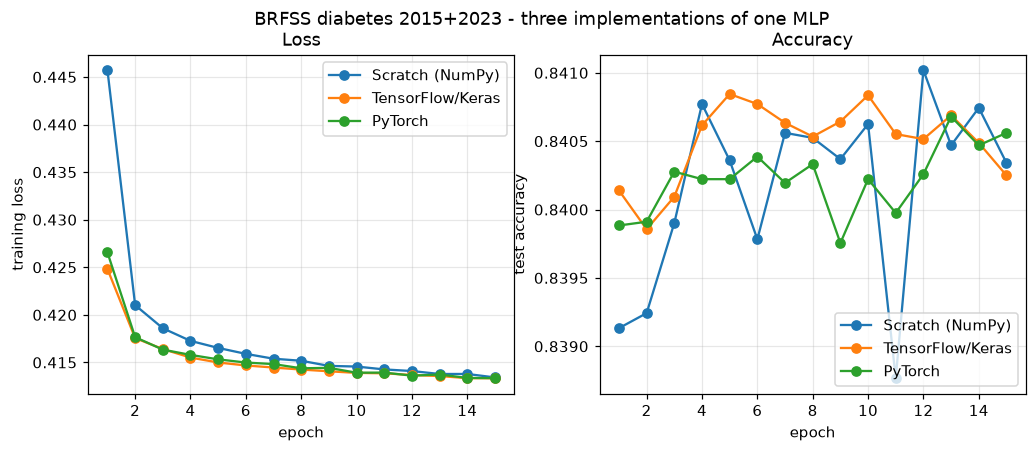

In [18]:
U.plot_history({r.framework: r.history for r in results},
               title=f"{meta['name']} - three implementations of one MLP")
plt.show()

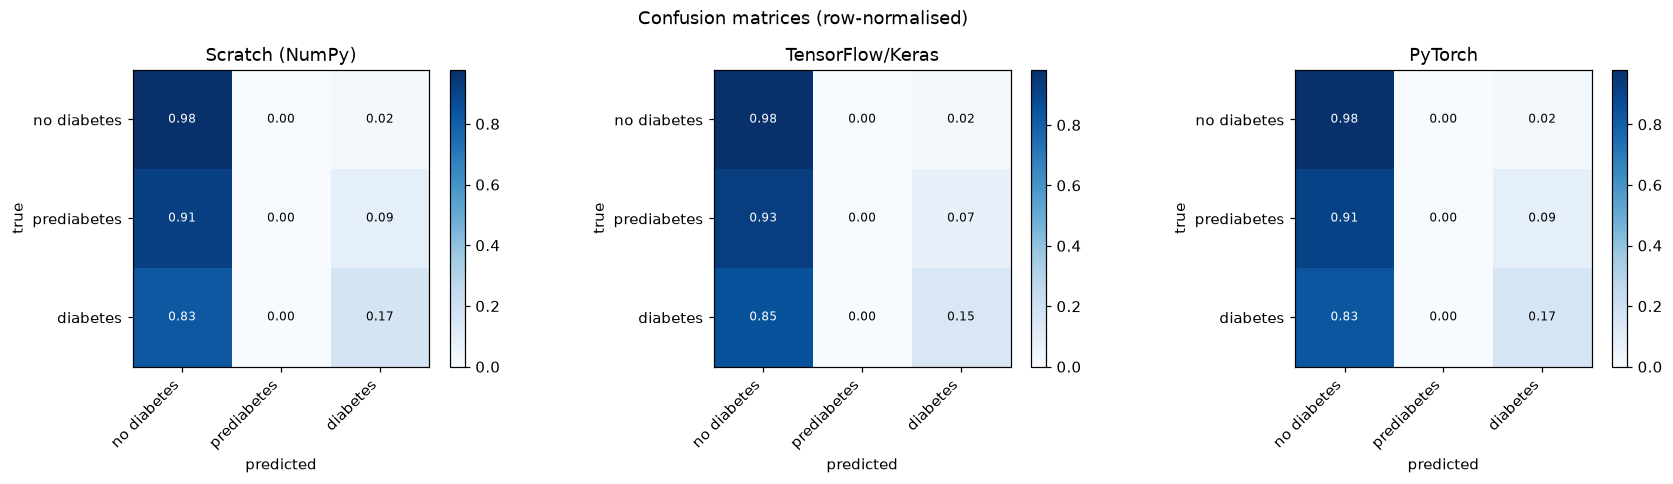

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, r in zip(axes, results):
    U.plot_confusion(r.confusion, CLASSES, title=r.framework, ax=ax)
fig.suptitle("Confusion matrices (row-normalised)")
fig.tight_layout(); plt.show()

Read the middle row of each matrix. `prediabetes` is 2.2 % of the data and essentially never predicted —
that whole row being dark is what a macro-F1 well below the accuracy is telling us numerically.

---
## 7. Handling the imbalance — the technique from `theory_notes.md` §4.2

Everything above is the **fair three-way comparison**: identical data, identical architecture, identical
hyperparameters. The experiment in this section deliberately breaks that symmetry, so it is reported
separately and never mixed into the comparison table.

§4.2 diagnoses the problem and names three remedies — class weighting, oversampling, or switching to a
PR-AUC-style metric. The cheapest is **class weighting**: make an error on a rare class cost proportionally
more, via

$$w_c = \frac{N}{K \cdot n_c}$$

so the ~2 % `prediabetes` class carries a weight roughly forty times that of the majority class.

The scratch leg sits this one out: `scratch_nn.SoftmaxCrossEntropy` takes no per-class weights, and adding
them would change a module the already-committed notebooks depend on. Keras and PyTorch both support it
directly, which is itself a result worth recording — the abstraction level buys you the *options*, not just
the convenience.

In [20]:
w = D.class_weights(y_train, N_CLASSES)
print(f"{'class':<24}{'count':>10}{'share':>9}{'weight':>10}")
for i, c in enumerate(CLASSES):
    print(f"{c:<24}{counts[i]:>10,}{counts[i]/counts.sum():>9.2%}{w[i]:>10.3f}")
print(f"\nweight ratio rarest/commonest: {w.max() / w.min():.1f}x")

class                        count    share    weight
no diabetes                365,369   83.62%     0.399
prediabetes                  9,468    2.17%    15.383
diabetes                    62,096   14.21%     2.345

weight ratio rarest/commonest: 38.6x


In [21]:
# Keras with class_weight=
U.set_seed(U.SEED)
keras_w = keras.Sequential([
    keras.layers.Input(shape=(N_FEATURES,)),
    keras.layers.Dense(HIDDEN1, activation="relu"),
    keras.layers.Dropout(DROPOUT),
    keras.layers.Dense(HIDDEN2, activation="relu"),
    keras.layers.Dense(N_CLASSES),
], name="brfss_mlp_weighted")
keras_w.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
with U.Timer() as t_kw:
    keras_w.fit(X_train, y_train, validation_data=(X_test, y_test),
                epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2,
                class_weight={i: float(w[i]) for i in range(N_CLASSES)})

pred_kw = keras_w.predict(X_test, batch_size=512, verbose=0).argmax(axis=1)
m_kw = U.evaluate(y_test, pred_kw, N_CLASSES)
print(f"\nKeras + class weights: accuracy {m_kw['test_accuracy']:.4f}   "
      f"macro-F1 {m_kw['f1_macro']:.4f}   ({t_kw.seconds:.1f}s)")

Epoch 1/15


1707/1707 - 3s - 2ms/step - accuracy: 0.5974 - loss: 0.9705 - val_accuracy: 0.5780 - val_loss: 0.9358


Epoch 2/15


1707/1707 - 3s - 1ms/step - accuracy: 0.6046 - loss: 0.9583 - val_accuracy: 0.5936 - val_loss: 0.9170


Epoch 3/15


...

Epoch 14/15


1707/1707 - 4s - 2ms/step - accuracy: 0.6103 - loss: 0.9468 - val_accuracy: 0.6007 - val_loss: 0.9012


Epoch 15/15


1707/1707 - 4s - 2ms/step - accuracy: 0.6088 - loss: 0.9466 - val_accuracy: 0.5922 - val_loss: 0.9099



Keras + class weights: accuracy 0.5922   macro-F1 0.4130   (46.2s)


In [22]:
# PyTorch with CrossEntropyLoss(weight=)
U.set_seed(U.SEED)
torch_w = BrfssMLP(N_FEATURES, N_CLASSES).to(DEVICE)
crit_w = nn.CrossEntropyLoss(weight=torch.tensor(w).to(DEVICE))
opt_w = torch.optim.Adam(torch_w.parameters(), lr=LR)

with U.Timer() as t_tw:
    for epoch in range(1, EPOCHS + 1):
        torch_w.train()
        running, nb = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt_w.zero_grad()
            loss = crit_w(torch_w(xb), yb)
            loss.backward()
            opt_w.step()
            running += loss.item(); nb += 1
        torch_w.eval()
        with torch.no_grad():
            acc = (torch_w(Xte_t).argmax(1).cpu().numpy() == y_test).mean()
        print(f"epoch {epoch}/{EPOCHS}  loss {running/nb:.4f}  test_acc {acc:.4f}")

torch_w.eval()
with torch.no_grad():
    pred_tw = torch_w(Xte_t).argmax(1).cpu().numpy()
m_tw = U.evaluate(y_test, pred_tw, N_CLASSES)
print(f"\nPyTorch + class weights: accuracy {m_tw['test_accuracy']:.4f}   "
      f"macro-F1 {m_tw['f1_macro']:.4f}   ({t_tw.seconds:.1f}s)")

epoch 1/15  loss 0.9634  test_acc 0.6236


epoch 2/15  loss 0.9553  test_acc 0.6495


epoch 3/15  loss 0.9535  test_acc 0.6161


epoch 4/15  loss 0.9515  test_acc 0.6373


epoch 5/15  loss 0.9509  test_acc 0.6287


...

epoch 11/15  loss 0.9466  test_acc 0.6203


epoch 12/15  loss 0.9462  test_acc 0.6581


epoch 13/15  loss 0.9462  test_acc 0.6425


epoch 14/15  loss 0.9451  test_acc 0.6158


epoch 15/15  loss 0.9455  test_acc 0.6550

PyTorch + class weights: accuracy 0.6550   macro-F1 0.4306   (67.7s)


,framework,class_weighted,test_accuracy,f1_macro
0,TensorFlow/Keras,no,0.8402,0.3823
1,TensorFlow/Keras,yes,0.5922,0.4130
2,PyTorch,no,0.8406,0.3888
3,PyTorch,yes,0.6550,0.4306


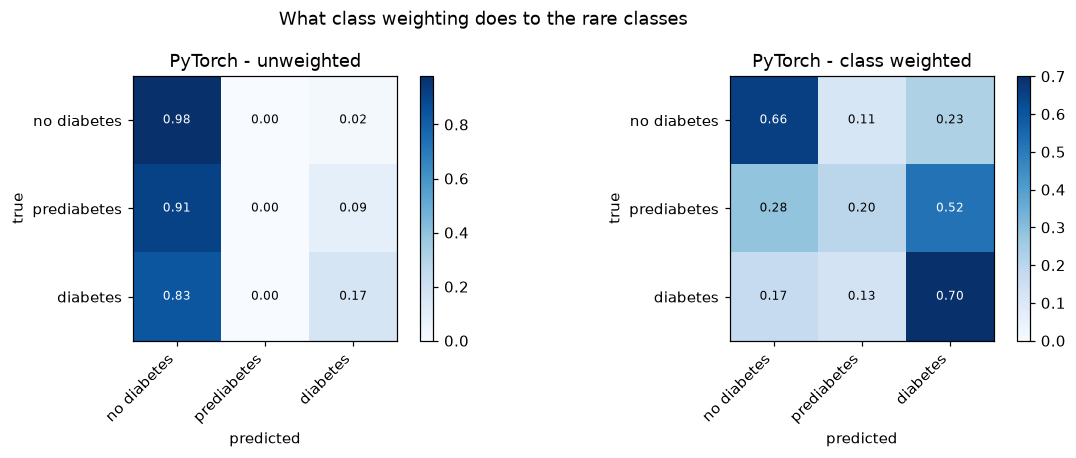

In [23]:
# What weighting actually traded away.
unweighted = {r.framework: r for r in results}
imbalance = pd.DataFrame([
    ["TensorFlow/Keras", "no",  unweighted["TensorFlow/Keras"].test_accuracy,
     unweighted["TensorFlow/Keras"].f1_macro],
    ["TensorFlow/Keras", "yes", m_kw["test_accuracy"], m_kw["f1_macro"]],
    ["PyTorch",          "no",  unweighted["PyTorch"].test_accuracy,
     unweighted["PyTorch"].f1_macro],
    ["PyTorch",          "yes", m_tw["test_accuracy"], m_tw["f1_macro"]],
], columns=["framework", "class_weighted", "test_accuracy", "f1_macro"]).round(4)
display(imbalance)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
U.plot_confusion(unweighted["PyTorch"].confusion, CLASSES,
                 title="PyTorch - unweighted", ax=axes[0])
U.plot_confusion(m_tw["confusion"], CLASSES,
                 title="PyTorch - class weighted", ax=axes[1])
fig.suptitle("What class weighting does to the rare classes")
fig.tight_layout(); plt.show()

**How to read this.** Class weighting almost always *lowers* accuracy while *raising* macro F1, and the
confusion matrices show why: the model stops answering with the majority class for everything, so it starts
catching real `diabetes` and `prediabetes` cases at the cost of more false alarms on the healthy majority.

Which of the two is "better" is not a machine-learning question. For a **community screening** instrument —
which is what BRFSS is, self-reported by telephone with no HbA1c or blood glucose anywhere in the file —
missing a diabetic is the expensive error and a false alarm merely means a follow-up test. That argues for
the weighted model, and it argues for reporting macro F1 as the headline number.

---
## 8. Where each component lives

This is the table slide 28 asks students to submit, filled in for this notebook.

In [24]:
component_table = pd.DataFrame([
    ["Data loading",     "ass4_newdata -> NumPy arrays", "same arrays",              "same arrays"],
    ["Preprocessing",    "ass4_newdata (shared)",        "shared",                   "shared"],
    ["Model definition", "S.Sequential([...])",          "keras.Sequential([...])",  "nn.Module + nn.Sequential"],
    ["Dense layer",      "S.Dense (x@W+b by hand)",      "keras.layers.Dense",       "nn.Linear"],
    ["Activation",       "S.ReLU (mask multiply)",       "activation='relu'",        "nn.ReLU"],
    ["Regularisation",   "S.Dropout (inverted)",         "keras.layers.Dropout",     "nn.Dropout"],
    ["Loss",             "S.SoftmaxCrossEntropy",        "SparseCategoricalCrossentropy", "nn.CrossEntropyLoss"],
    ["Class weighting",  "not supported",                "fit(class_weight=...)",    "CrossEntropyLoss(weight=...)"],
    ["Gradient",         "hand-derived backward()",      "automatic (GradientTape)", "automatic (autograd)"],
    ["Optimizer",        "S.Adam (written out)",         "keras.optimizers.Adam",    "torch.optim.Adam"],
    ["Training loop",    "explicit for-loop",            "model.fit()",              "explicit for-loop"],
    ["Evaluation",       "predict_classes + sklearn",    "predict + sklearn",        "forward + sklearn"],
], columns=["Component", "Scratch", "TensorFlow/Keras", "PyTorch"])

display(component_table)

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,ass4_newdata -> NumPy arrays,same arrays,same arrays
1,Preprocessing,ass4_newdata (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module + nn.Sequential
3,Dense layer,S.Dense (x@W+b by hand),keras.layers.Dense,nn.Linear
4,Activation,S.ReLU (mask multiply),activation='relu',nn.ReLU
5,Regularisation,S.Dropout (inverted),keras.layers.Dropout,nn.Dropout
6,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
7,Class weighting,not supported,fit(class_weight=...),CrossEntropyLoss(weight=...)
8,Gradient,hand-derived backward(),automatic (GradientTape),automatic (autograd)
9,Optimizer,S.Adam (written out),keras.optimizers.Adam,torch.optim.Adam


In [25]:
# Persist for 05_compare.ipynb
payload = {
    "meta": {k: v for k, v in meta.items() if k != "feature_names"},
    "results": [r.__dict__ for r in results],
    "component_table": component_table.to_dict(orient="records"),
    "baseline": {"strategy": f"always predict '{CLASSES[majority]}'", **{
        k: v for k, v in base.items() if k != "confusion"}},
    "class_weighting": imbalance.to_dict(orient="records"),
}
path = os.path.join(RESULTS, "n01_diabetes_brfss.json")
with open(path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, default=str)
print("saved", os.path.relpath(path, D.HERE))

saved results\n01_diabetes_brfss.json


## Saving the trained models

The JSON above records what the models *scored*. It does not record what they *are* — rerunning any of
these numbers would mean retraining from scratch.

`U.save_model` writes each leg in its framework's native format, under `results/models/<notebook>/`, with a
JSON sidecar naming the architecture and the score the weights actually produced:

| leg | file | reloads alone? |
|---|---|---|
| Scratch (NumPy) | `.npz`, one array per layer parameter | no |
| TensorFlow/Keras | `.keras`, graph + weights | **yes** |
| PyTorch | `.pt`, `state_dict` | no |

`.pt` and `.npz` hold weights only, so reloading them means rebuilding the architecture first and passing
the fresh instance to `U.load_model(..., model=...)`.

In [26]:
# Weights are the model; metrics only describe it. Persist all three legs,
# plus the two class-weighted variants from section 7.
TAG = "n01_diabetes_brfss"

by_fw = {r.framework: r for r in results}

for obj, fw, stem in [
    (scratch_model, "Scratch (NumPy)",  "mlp_scratch"),
    (keras_model,   "TensorFlow/Keras", "mlp_keras"),
    (torch_model,   "PyTorch",          "mlp_torch"),
]:
    r = by_fw[fw]
    U.save_model(obj, stem, TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro,
                 class_weighted=False)

U.save_model(keras_w, "mlp_keras_weighted", TAG, architecture=ARCH, dataset=meta["name"],
             epochs=EPOCHS, test_accuracy=m_kw["test_accuracy"], f1_macro=m_kw["f1_macro"],
             class_weighted=True)
U.save_model(torch_w, "mlp_torch_weighted", TAG, architecture=ARCH, dataset=meta["name"],
             epochs=EPOCHS, test_accuracy=m_tw["test_accuracy"], f1_macro=m_tw["f1_macro"],
             class_weighted=True)

display(U.list_models(TAG)[["name", "framework", "n_params", "dataset", "test_accuracy", "f1_macro"]])

saved notebook\models\n01_diabetes_brfss\mlp_scratch.npz  (11,011 params, 41 KB)
saved notebook\models\n01_diabetes_brfss\mlp_keras.keras  (11,011 params, 156 KB)
saved notebook\models\n01_diabetes_brfss\mlp_torch.pt  (11,011 params, 46 KB)
saved notebook\models\n01_diabetes_brfss\mlp_keras_weighted.keras  (11,011 params, 156 KB)
saved notebook\models\n01_diabetes_brfss\mlp_torch_weighted.pt  (11,011 params, 46 KB)


,name,framework,n_params,dataset,test_accuracy,f1_macro
0,mlp_keras,keras,11011,BRFSS diabetes 2015+2023,0.840250,0.382277
1,mlp_keras_weighted,keras,11011,BRFSS diabetes 2015+2023,0.592193,0.413013
2,mlp_scratch,scratch,11011,BRFSS diabetes 2015+2023,0.840341,0.391931
3,mlp_torch,torch,11011,BRFSS diabetes 2015+2023,0.840561,0.388798
4,mlp_torch_weighted,torch,11011,BRFSS diabetes 2015+2023,0.654994,0.430565


---
## 9. What this dataset shows

**The three implementations agree.** All three build the same 11,011-parameter function, and all three land
within noise of each other on accuracy and macro F1. Different names — `S.Dense`, `keras.layers.Dense`,
`nn.Linear` — do not imply different machine-learning concepts. The abstraction level changed; the
mathematics did not.

**Every leg trained on the full dataset.** With 19 features rather than 179, even the pure-NumPy
implementation handles all 436,933 training rows, so unlike the image notebooks there is no subset caveat
attached to the scratch row. This is the cleanest three-way comparison in the whole assignment.

**Accuracy is the wrong headline.** With an 84 / 2 / 14 split, always answering `no diabetes` scores ~84 %
— higher than some genuinely-trained models will reach once they start spending capacity on the rare
classes. Macro F1 is what separates a model that learned something from one that learned the prior, and
§7 shows class weighting trading accuracy for exactly that.

**The tabular case is the control.** No convolution appears anywhere in this notebook, because there is no
spatial neighbourhood for a kernel to exploit. That is what makes notebook 02 meaningful: when the rice
images introduce `Conv2D`, it will be a response to a property the data actually has, not a default choice.